In [2]:
# ============================================================
# BLOCO - Funções para seleção de lambda no FAGTB
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from fagtb_core import FAGTB


# ============================================================
# Métricas auxiliares
# ============================================================

def _safe_div(num, den):
    return np.nan if den == 0 else num / den


def taxas_por_grupo(y_true, y_pred, sensitive, grupo):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive)

    mask = sensitive == grupo

    yt = y_true[mask]
    yp = y_pred[mask]

    tp = np.sum((yt == 1) & (yp == 1))
    fn = np.sum((yt == 1) & (yp == 0))
    fp = np.sum((yt == 0) & (yp == 1))
    tn = np.sum((yt == 0) & (yp == 0))

    tpr = _safe_div(tp, tp + fn)
    fpr = _safe_div(fp, fp + tn)

    return tpr, fpr


def equal_opportunity_diff(
    y_true,
    y_pred,
    sensitive,
    grupo_privilegiado,
    grupo_desprivilegiado
):
    tpr_priv, _ = taxas_por_grupo(
        y_true,
        y_pred,
        sensitive,
        grupo_privilegiado
    )

    tpr_des, _ = taxas_por_grupo(
        y_true,
        y_pred,
        sensitive,
        grupo_desprivilegiado
    )

    return abs(tpr_priv - tpr_des)


def equalized_odds_diff(
    y_true,
    y_pred,
    sensitive,
    grupo_privilegiado,
    grupo_desprivilegiado
):
    tpr_priv, fpr_priv = taxas_por_grupo(
        y_true,
        y_pred,
        sensitive,
        grupo_privilegiado
    )

    tpr_des, fpr_des = taxas_por_grupo(
        y_true,
        y_pred,
        sensitive,
        grupo_desprivilegiado
    )

    return 0.5 * (
        abs(tpr_priv - tpr_des) +
        abs(fpr_priv - fpr_des)
    )


def demographic_parity_diff(
    y_pred,
    sensitive,
    grupo_privilegiado,
    grupo_desprivilegiado
):
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive)

    taxa_priv = y_pred[sensitive == grupo_privilegiado].mean()
    taxa_des = y_pred[sensitive == grupo_desprivilegiado].mean()

    return abs(taxa_priv - taxa_des)


def p_rule_percent(
    y_pred,
    sensitive,
    grupo_privilegiado,
    grupo_desprivilegiado
):
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive)

    taxa_priv = y_pred[sensitive == grupo_privilegiado].mean()
    taxa_des = y_pred[sensitive == grupo_desprivilegiado].mean()

    if taxa_priv == 0 or taxa_des == 0:
        return 0.0

    return min(
        taxa_des / taxa_priv,
        taxa_priv / taxa_des
    ) * 100


def avaliar_modelo(
    y_true,
    y_pred,
    sensitive,
    grupo_privilegiado,
    grupo_desprivilegiado
):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),

        "equal_opportunity": equal_opportunity_diff(
            y_true,
            y_pred,
            sensitive,
            grupo_privilegiado,
            grupo_desprivilegiado
        ),

        "equalized_odds": equalized_odds_diff(
            y_true,
            y_pred,
            sensitive,
            grupo_privilegiado,
            grupo_desprivilegiado
        ),

        "demographic_parity": demographic_parity_diff(
            y_pred,
            sensitive,
            grupo_privilegiado,
            grupo_desprivilegiado
        ),

        "p_rule": p_rule_percent(
            y_pred,
            sensitive,
            grupo_privilegiado,
            grupo_desprivilegiado
        )
    }


# ============================================================
# Instanciação padronizada do FAGTB
# ============================================================

def criar_fagtb(
    n_estimators=100,
    learning_rate=0.1,
    min_samples_split=2,
    min_impurity=1e-7,
    max_depth=9,
    max_features=None,
    regression=False
):
    return FAGTB(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        min_samples_split=min_samples_split,
        min_impurity=min_impurity,
        max_depth=max_depth,
        max_features=max_features,
        regression=regression
    )


# ============================================================
# Escolha automática do lambda
# ============================================================

def escolher_lambda_antes_despencar(
    df_val,
    metrica_desempenho="balanced_accuracy",
    metrica_justica="equalized_odds",
    queda_brusca_minima=0.05
):
    """
    Escolhe o lambda imediatamente anterior à primeira queda brusca
    da métrica de desempenho.

    Exemplo:
    se balanced_accuracy cai muito de lambda=0.3 para lambda=1.0,
    escolhe lambda=0.3.

    Se nenhuma queda brusca for detectada, escolhe o lambda com
    menor métrica de justiça, usando desempenho como desempate.
    """

    df_ord = df_val.copy()
    df_ord = df_ord.sort_values("lambda").reset_index(drop=True)

    df_ord["queda_desempenho"] = (
        df_ord[metrica_desempenho].shift(1) -
        df_ord[metrica_desempenho]
    )

    colapsos = df_ord[
        df_ord["queda_desempenho"] >= queda_brusca_minima
    ]

    if not colapsos.empty:
        idx_colapso = colapsos.index[0]

        if idx_colapso == 0:
            melhor_idx = 0
        else:
            melhor_idx = idx_colapso - 1

        melhor_lambda = df_ord.loc[melhor_idx, "lambda"]

        info_escolha = {
            "criterio": "antes_da_primeira_queda_brusca",
            "metrica_desempenho": metrica_desempenho,
            "metrica_justica": metrica_justica,
            "queda_brusca_minima": queda_brusca_minima,

            "lambda_antes_queda": melhor_lambda,
            "lambda_onde_caiu": df_ord.loc[idx_colapso, "lambda"],
            "queda_detectada": df_ord.loc[idx_colapso, "queda_desempenho"],

            "valor_antes_queda": df_ord.loc[melhor_idx, metrica_desempenho],
            "valor_depois_queda": df_ord.loc[idx_colapso, metrica_desempenho]
        }

        return melhor_lambda, info_escolha, df_ord

    # --------------------------------------------------------
    # Fallback:
    # se não houve queda brusca, escolhe menor Equalized Odds
    # --------------------------------------------------------

    candidatos = df_ord.sort_values(
        by=[metrica_justica, metrica_desempenho, "accuracy"],
        ascending=[True, False, False]
    )

    melhor_lambda = candidatos.iloc[0]["lambda"]

    info_escolha = {
        "criterio": "menor_justica_sem_queda_brusca_detectada",
        "metrica_desempenho": metrica_desempenho,
        "metrica_justica": metrica_justica,
        "queda_brusca_minima": queda_brusca_minima,

        "lambda_antes_queda": None,
        "lambda_onde_caiu": None,
        "queda_detectada": None,

        "valor_antes_queda": None,
        "valor_depois_queda": None
    }

    return melhor_lambda, info_escolha, df_ord


# ============================================================
# Gráfico único com dois eixos Y
# ============================================================

def plotar_tradeoff_lambda_duplo_eixo(
    df_resultados,
    melhor_lambda=None,
    info_escolha=None,
    nome_experimento="fagtb",
    cenario="aware",
    pasta_figuras="resultados/mitigacoes/fagtb_lambda/figuras",
    salvar_figura=True,
    mostrar_figura=True,
    dpi=200
):
    df_val = df_resultados[df_resultados["split"] == "validacao"].copy()
    df_val = df_val.sort_values("lambda")

    pasta_figuras = Path(pasta_figuras)
    pasta_figuras.mkdir(parents=True, exist_ok=True)

    fig, ax1 = plt.subplots(figsize=(11, 5.5))

    # ========================================================
    # Eixo Y esquerdo: desempenho tradicional
    # ========================================================

    ax1.plot(
        df_val["lambda"],
        df_val["accuracy"],
        marker="o",
        label="Accuracy"
    )

    ax1.plot(
        df_val["lambda"],
        df_val["f1"],
        marker="o",
        label="F1"
    )

    ax1.plot(
        df_val["lambda"],
        df_val["balanced_accuracy"],
        marker="o",
        label="Balanced Accuracy"
    )

    ax1.set_xlabel("Lambda")
    ax1.set_ylabel("Desempenho tradicional")
    ax1.set_xscale("symlog", linthresh=0.001)
    ax1.grid(True)

    # ========================================================
    # Eixo Y direito: justiça
    # ========================================================

    ax2 = ax1.twinx()

    ax2.plot(
        df_val["lambda"],
        df_val["equalized_odds"],
        marker="s",
        linestyle="--",
        label="Equalized Odds"
    )

    ax2.plot(
        df_val["lambda"],
        df_val["equal_opportunity"],
        marker="s",
        linestyle="--",
        label="Equal Opportunity"
    )

    ax2.set_ylabel("Diferença de justiça")

    # ========================================================
    # Marca lambda escolhido
    # ========================================================

    if melhor_lambda is not None:
        ax1.axvline(
            x=melhor_lambda,
            linestyle=":",
            linewidth=2,
            label=f"Lambda escolhido = {melhor_lambda}"
        )

    # Marca onde ocorreu a queda brusca
    if info_escolha is not None:
        lambda_onde_caiu = info_escolha.get("lambda_onde_caiu")

        if lambda_onde_caiu is not None:
            ax1.axvline(
                x=lambda_onde_caiu,
                linestyle=":",
                linewidth=1,
                label=f"Queda detectada = {lambda_onde_caiu}"
            )

    # ========================================================
    # Legenda combinada
    # ========================================================

    linhas_1, labels_1 = ax1.get_legend_handles_labels()
    linhas_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        linhas_1 + linhas_2,
        labels_1 + labels_2,
        loc="center right"
    )

    titulo = f"Trade-off desempenho vs justiça - {nome_experimento} - {cenario}"
    plt.title(titulo)

    fig.tight_layout()

    # ========================================================
    # Salva figura
    # ========================================================

    caminho_figura = None

    if salvar_figura:
        nome_arquivo = f"{nome_experimento}_{cenario}_tradeoff_lambda.png"
        caminho_figura = pasta_figuras / nome_arquivo

        fig.savefig(
            caminho_figura,
            dpi=dpi,
            bbox_inches="tight"
        )

        print(f"Figura salva em: {caminho_figura}")

    if mostrar_figura:
        plt.show()

    plt.close(fig)

    return caminho_figura


# ============================================================
# Função principal: testar lambdas
# ============================================================

def testar_lambdas_fagtb(
    X_train,
    X_test,
    y_train,
    y_test,
    atributo_sensivel,
    grupo_privilegiado,
    grupo_desprivilegiado,
    lambdas=None,
    usar_atributo_sensivel_no_modelo=True,
    random_state=42,
    test_size_validacao=0.25,

    # Nova regra de escolha
    metrica_despencar="balanced_accuracy",
    queda_brusca_minima=0.05,
    metrica_justica="equalized_odds",

    pasta_saida="resultados/mitigacoes/fagtb_lambda",
    nome_experimento="fagtb",
    salvar_modelo=True,
    parametros_fagtb=None,
    gerar_grafico=True
):
    """
    Testa vários lambdas do FAGTB usando um conjunto de validação.

    Escolha automática:
    - ordena os lambdas;
    - calcula a queda da métrica de desempenho entre lambdas consecutivos;
    - detecta a primeira queda brusca;
    - escolhe o lambda imediatamente anterior à queda;
    - se não houver queda brusca, escolhe o menor valor da métrica de justiça.

    Recomendações:
    - metrica_despencar="balanced_accuracy"
    - metrica_justica="equalized_odds"
    - queda_brusca_minima=0.05
    """

    if lambdas is None:
        lambdas = [
            0.0,
            0.001,
            0.003,
            0.01,
            0.03,
            0.1,
            0.3,
            1.0,
            3.0,
            10.0
        ]

    if parametros_fagtb is None:
        parametros_fagtb = {
            "n_estimators": 100,
            "learning_rate": 0.1,
            "min_samples_split": 2,
            "min_impurity": 1e-7,
            "max_depth": 9,
            "max_features": None,
            "regression": False
        }

    pasta_saida = Path(pasta_saida)
    pasta_saida.mkdir(parents=True, exist_ok=True)

    X_train = X_train.copy().reset_index(drop=True)
    X_test = X_test.copy().reset_index(drop=True)

    y_train = pd.Series(y_train).astype(int).reset_index(drop=True)
    y_test = pd.Series(y_test).astype(int).reset_index(drop=True)

    s_train = X_train[atributo_sensivel].astype(int).reset_index(drop=True)
    s_test = X_test[atributo_sensivel].astype(int).reset_index(drop=True)

    # ========================================================
    # Split interno: treino/validação
    # ========================================================

    X_fit, X_val, y_fit, y_val, s_fit, s_val = train_test_split(
        X_train,
        y_train,
        s_train,
        test_size=test_size_validacao,
        random_state=random_state,
        stratify=y_train
    )

    # ========================================================
    # Cenário aware/unaware
    # ========================================================

    if usar_atributo_sensivel_no_modelo:
        X_fit_model = X_fit.copy()
        X_val_model = X_val.copy()
        X_train_model = X_train.copy()
        X_test_model = X_test.copy()
        sufixo = "aware"
    else:
        X_fit_model = X_fit.drop(
            columns=[atributo_sensivel],
            errors="ignore"
        )

        X_val_model = X_val.drop(
            columns=[atributo_sensivel],
            errors="ignore"
        )

        X_train_model = X_train.drop(
            columns=[atributo_sensivel],
            errors="ignore"
        )

        X_test_model = X_test.drop(
            columns=[atributo_sensivel],
            errors="ignore"
        )

        sufixo = "unaware"

    resultados = []

    print("\n" + "=" * 80)
    print(f"Teste de lambdas FAGTB | {nome_experimento} | {sufixo}")
    print("=" * 80)

    # ========================================================
    # Testa lambdas na validação
    # ========================================================

    for lambda_ in lambdas:

        print("\n" + "-" * 80)
        print(f"Treinando lambda = {lambda_}")
        print("-" * 80)

        modelo = criar_fagtb(**parametros_fagtb)

        modelo.fit(
            X_fit_model,
            y_fit.values,
            s_fit.values,
            LAMBDA=lambda_,
            Xtest=X_val_model,
            yt=y_val.values,
            sensitivet=s_val.values
        )

        y_pred_val = modelo.predict(X_val_model)

        metricas = avaliar_modelo(
            y_true=y_val.values,
            y_pred=y_pred_val,
            sensitive=s_val.values,
            grupo_privilegiado=grupo_privilegiado,
            grupo_desprivilegiado=grupo_desprivilegiado
        )

        linha = {
            "dataset_config": nome_experimento,
            "cenario": sufixo,
            "split": "validacao",
            "lambda": lambda_,
            **metricas
        }

        resultados.append(linha)

        print(
            f"lambda={lambda_} | "
            f"acc={metricas['accuracy']:.4f} | "
            f"bal_acc={metricas['balanced_accuracy']:.4f} | "
            f"f1={metricas['f1']:.4f} | "
            f"EOdds={metricas['equalized_odds']:.4f} | "
            f"EOp={metricas['equal_opportunity']:.4f} | "
            f"p-rule={metricas['p_rule']:.2f}"
        )

    df_resultados = pd.DataFrame(resultados)

    # ========================================================
    # Escolha automática: ponto antes de despencar
    # ========================================================

    df_val = df_resultados[
        df_resultados["split"] == "validacao"
    ].copy()

    melhor_lambda, info_escolha, df_val_diagnostico = (
        escolher_lambda_antes_despencar(
            df_val=df_val,
            metrica_desempenho=metrica_despencar,
            metrica_justica=metrica_justica,
            queda_brusca_minima=queda_brusca_minima
        )
    )

    print("\n" + "=" * 80)
    print("Escolha automática")
    print("=" * 80)
    print(f"Critério: {info_escolha['criterio']}")
    print(f"Métrica para detectar queda: {metrica_despencar}")
    print(f"Queda brusca mínima: {queda_brusca_minima}")
    print(f"Métrica de justiça fallback: {metrica_justica}")
    print(f"Melhor lambda escolhido: {melhor_lambda}")

    if info_escolha["lambda_onde_caiu"] is not None:
        print(
            f"Queda detectada de {info_escolha['lambda_antes_queda']} "
            f"para {info_escolha['lambda_onde_caiu']}: "
            f"{info_escolha['valor_antes_queda']:.4f} -> "
            f"{info_escolha['valor_depois_queda']:.4f} "
            f"(queda = {info_escolha['queda_detectada']:.4f})"
        )

    # Salva diagnóstico das quedas
    caminho_diag = (
        pasta_saida /
        f"{nome_experimento}_{sufixo}_diagnostico_quedas.csv"
    )

    df_val_diagnostico.to_csv(caminho_diag, index=False)

    # ========================================================
    # Treina modelo final com treino inteiro e avalia no teste
    # ========================================================

    print("\n" + "=" * 80)
    print(f"Treinando modelo final com lambda = {melhor_lambda}")
    print("=" * 80)

    modelo_final = criar_fagtb(**parametros_fagtb)

    modelo_final.fit(
        X_train_model,
        y_train.values,
        s_train.values,
        LAMBDA=melhor_lambda,
        Xtest=X_test_model,
        yt=y_test.values,
        sensitivet=s_test.values
    )

    y_pred_test = modelo_final.predict(X_test_model)

    metricas_teste = avaliar_modelo(
        y_true=y_test.values,
        y_pred=y_pred_test,
        sensitive=s_test.values,
        grupo_privilegiado=grupo_privilegiado,
        grupo_desprivilegiado=grupo_desprivilegiado
    )

    linha_teste = {
        "dataset_config": nome_experimento,
        "cenario": sufixo,
        "split": "teste_final",
        "lambda": melhor_lambda,
        **metricas_teste
    }

    df_resultados = pd.concat(
        [
            df_resultados,
            pd.DataFrame([linha_teste])
        ],
        ignore_index=True
    )

    # Guarda informações da escolha no dataframe final
    df_resultados["lambda_escolhido"] = melhor_lambda
    df_resultados["criterio_escolha"] = info_escolha["criterio"]
    df_resultados["metrica_despencar"] = metrica_despencar
    df_resultados["queda_brusca_minima"] = queda_brusca_minima

    print("\nResultado final no teste:")
    print(
        f"lambda={melhor_lambda} | "
        f"acc={metricas_teste['accuracy']:.4f} | "
        f"bal_acc={metricas_teste['balanced_accuracy']:.4f} | "
        f"f1={metricas_teste['f1']:.4f} | "
        f"EOdds={metricas_teste['equalized_odds']:.4f} | "
        f"EOp={metricas_teste['equal_opportunity']:.4f} | "
        f"p-rule={metricas_teste['p_rule']:.2f}"
    )

    # ========================================================
    # Salva arquivos
    # ========================================================

    caminho_csv = (
        pasta_saida /
        f"{nome_experimento}_{sufixo}_lambdas.csv"
    )

    df_resultados.to_csv(caminho_csv, index=False)

    if salvar_modelo:
        caminho_modelo = (
            pasta_saida /
            f"{nome_experimento}_{sufixo}_lambda_{melhor_lambda}.joblib"
        )

        joblib.dump(modelo_final, caminho_modelo)

    print(f"\nResultados salvos em: {caminho_csv}")
    print(f"Diagnóstico das quedas salvo em: {caminho_diag}")

    # ========================================================
    # Gráfico único com dois eixos Y
    # ========================================================

    if gerar_grafico:
        plotar_tradeoff_lambda_duplo_eixo(
            df_resultados=df_resultados,
            melhor_lambda=melhor_lambda,
            info_escolha=info_escolha,
            nome_experimento=nome_experimento,
            cenario=sufixo
        )

    return df_resultados, modelo_final, melhor_lambda, info_escolha

import pandas as pd
from pathlib import Path

# ============================================================
# Carrega splits já salvos
# ============================================================

def remover_colunas_indice(df):
    """
    Remove colunas de índice salvas acidentalmente pelo pandas,
    como 'Unnamed: 0'.
    """
    return df.loc[:, ~df.columns.str.contains("^Unnamed")]


def carregar_splits_salvos(nome_dataset, pasta_splits="resultados/splits"):
    pasta_splits = Path(pasta_splits)

    caminho_X_train = pasta_splits / f"{nome_dataset}_X_train.csv"
    caminho_X_test = pasta_splits / f"{nome_dataset}_X_test.csv"
    caminho_y_train = pasta_splits / f"{nome_dataset}_y_train.csv"
    caminho_y_test = pasta_splits / f"{nome_dataset}_y_test.csv"

    X_train = pd.read_csv(caminho_X_train)
    X_test = pd.read_csv(caminho_X_test)
    y_train = pd.read_csv(caminho_y_train)
    y_test = pd.read_csv(caminho_y_test)

    X_train = remover_colunas_indice(X_train)
    X_test = remover_colunas_indice(X_test)
    y_train = remover_colunas_indice(y_train)
    y_test = remover_colunas_indice(y_test)

    # y normalmente vem como DataFrame de uma coluna.
    # Aqui convertemos para Series.
    if isinstance(y_train, pd.DataFrame):
        if y_train.shape[1] != 1:
            raise ValueError(f"{caminho_y_train} deveria ter apenas uma coluna.")
        y_train = y_train.iloc[:, 0]

    if isinstance(y_test, pd.DataFrame):
        if y_test.shape[1] != 1:
            raise ValueError(f"{caminho_y_test} deveria ter apenas uma coluna.")
        y_test = y_test.iloc[:, 0]

    # Garante alinhamento limpo de índice
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.astype(int).reset_index(drop=True)
    y_test = y_test.astype(int).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

# Exemplo de uso


####################################################################################################
DATASET: compas
####################################################################################################

Dataset: compas
Config sensível: african_american_0
Atributo sensível: African-American

Teste de lambdas FAGTB | compas_african_american_0 | aware

--------------------------------------------------------------------------------
Treinando lambda = 0.0
--------------------------------------------------------------------------------

0 87.32626276982168 2203.949778031717 2203.949778031717 Accuracy: 0.5446  test :  0.544  Prule Train :  1.0  Prule test :  1.0
5 1422.2519941145501 2087.809264521501 2087.809264521501 Accuracy: 0.6846  test :  0.6191  Prule Train :  0.8749430711404976  Prule test :  0.8498500475459001
10 2008.7247861173132 1994.4177980407121 1994.4177980407121 Accuracy: 0.7356  test :  0.6515  Prule Train :  0.7869608205177075  Prule test :  0.81045279962794

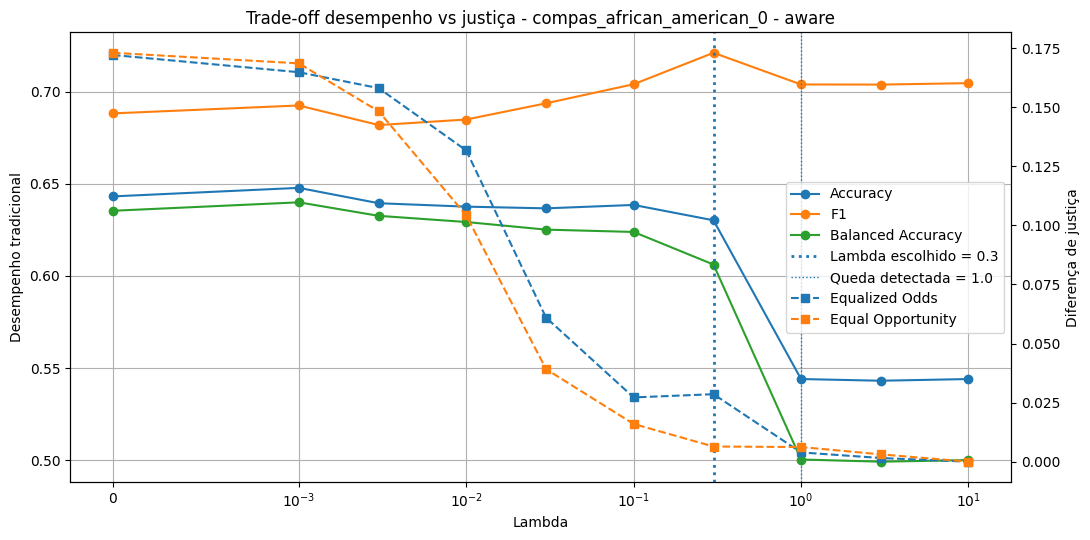


Dataset: compas
Config sensível: caucasian_1
Atributo sensível: Caucasian

Teste de lambdas FAGTB | compas_caucasian_1 | aware

--------------------------------------------------------------------------------
Treinando lambda = 0.0
--------------------------------------------------------------------------------
0 674.318887655991 2203.949778031717 2203.949778031717 Accuracy: 0.5446  test :  0.544  Prule Train :  1.0  Prule test :  1.0
5 2019.3900559327942 2087.809264521501 2087.809264521501 Accuracy: 0.6846  test :  0.6191  Prule Train :  0.9118945151542899  Prule test :  0.8956826099295447
10 2388.968459566273 1994.4177980407121 1994.4177980407121 Accuracy: 0.7356  test :  0.6515  Prule Train :  0.8501295604271164  Prule test :  0.8920056100981768
15 26.033577829938103 1916.7936017821999 1916.7936017821999 Accuracy: 0.7593  test :  0.6423  Prule Train :  0.823520798863786  Prule test :  0.8739865587052978
20 1425.9697092333565 1850.8713427371845 1850.8713427371845 Accuracy: 0.7714  t

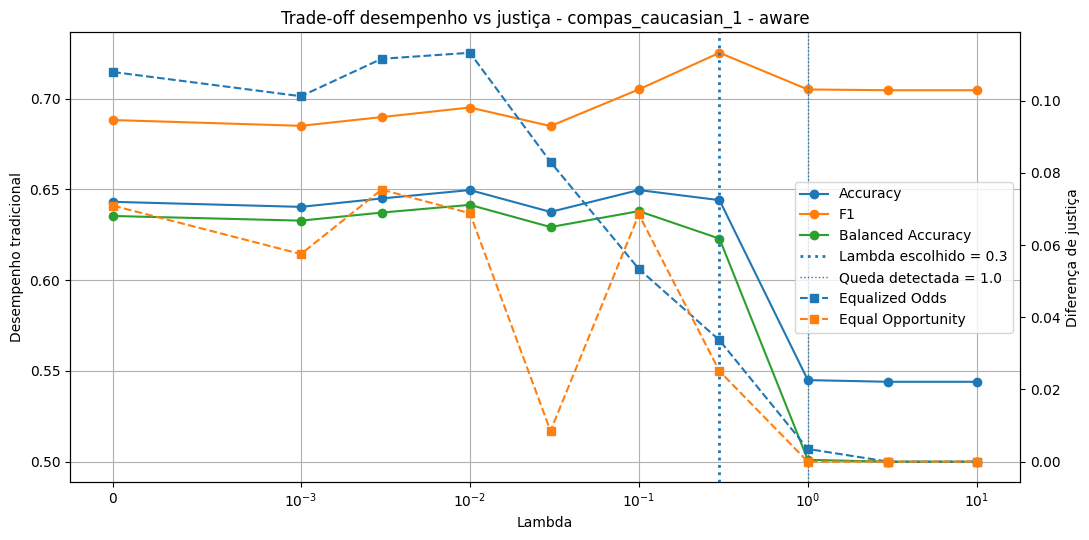


####################################################################################################
DATASET: hmda
####################################################################################################

Dataset: hmda
Config sensível: african_american_0
Atributo sensível: Applicant_African-American

Teste de lambdas FAGTB | hmda_african_american_0 | aware

--------------------------------------------------------------------------------
Treinando lambda = 0.0
--------------------------------------------------------------------------------
0 13144.14554814373 6763.243336588473 6763.243336588473 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
5 6887.722054127775 6336.860502676683 6336.860502676683 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
10 2848.715520377364 5977.748111510443 5977.748111510443 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
15 26104.775035713028 5680.025284403278 5680.025284403278

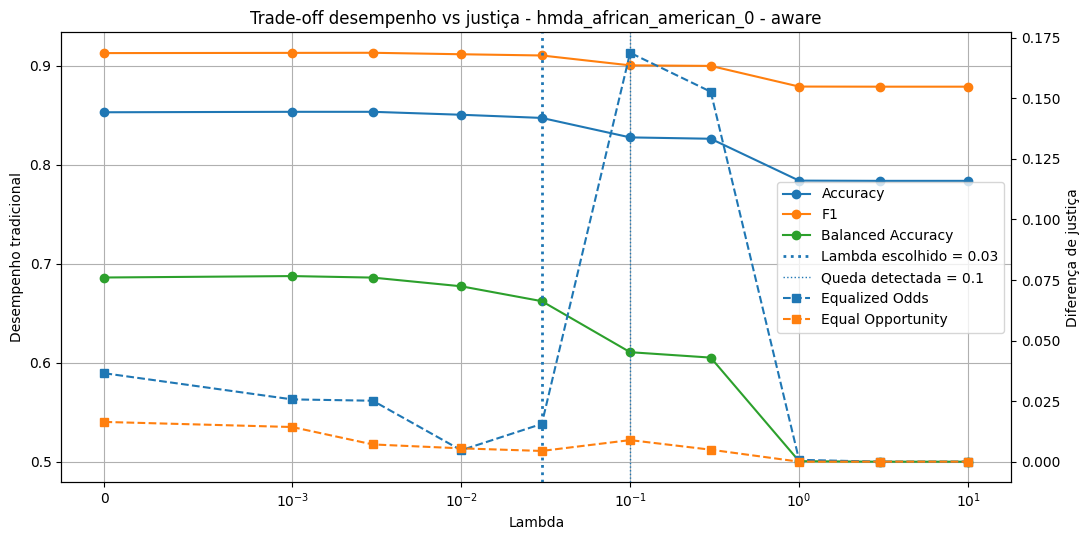


Dataset: hmda
Config sensível: caucasian_1
Atributo sensível: Applicant_Caucasian

Teste de lambdas FAGTB | hmda_caucasian_1 | aware

--------------------------------------------------------------------------------
Treinando lambda = 0.0
--------------------------------------------------------------------------------
0 3594.356790057166 6763.243336588473 6763.243336588473 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
5 46320.3059064202 6336.860502676683 6336.860502676683 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
10 19906.223610994763 5977.748111510443 5977.748111510443 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
15 26572.146964853255 5680.025284403278 5680.025284403278 Accuracy: 0.7836  test :  0.7835  Prule Train :  1.0  Prule test :  1.0
20 40086.9297441859 5431.3275931028775 5431.3275931028775 Accuracy: 0.8448  test :  0.8393  Prule Train :  0.9692644947449068  Prule test :  0.96149558143873
25 4053

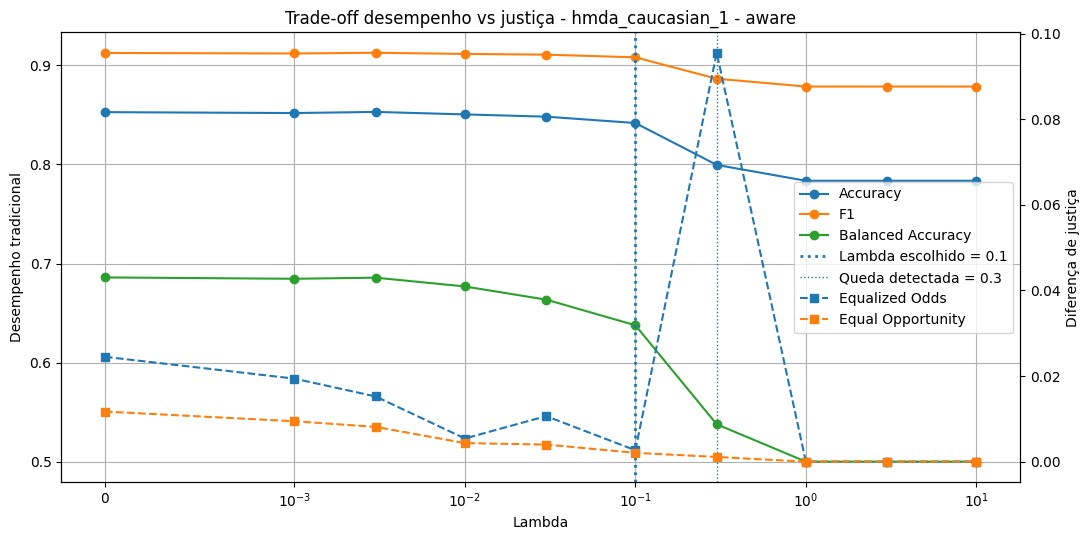

,dataset,config_sensivel,atributo_sensivel,grupo_privilegiado,grupo_desprivilegiado,lambda_fagtb,criterio_escolha,metrica_despencar,queda_brusca_minima,lambda_onde_caiu,queda_detectada,valor_antes_queda,valor_depois_queda
0,compas,african_american_0,African-American,0,1,0.30,antes_da_primeira_queda_brusca,balanced_accuracy,0.05,1.0,0.105861,0.606190,0.500329
1,compas,caucasian_1,Caucasian,1,0,0.30,antes_da_primeira_queda_brusca,balanced_accuracy,0.05,1.0,0.121898,0.622914,0.501016
2,hmda,african_american_0,Applicant_African-American,0,1,0.03,antes_da_primeira_queda_brusca,balanced_accuracy,0.05,0.1,0.051521,0.662064,0.610544
3,hmda,caucasian_1,Applicant_Caucasian,1,0,0.10,antes_da_primeira_queda_brusca,balanced_accuracy,0.05,0.3,0.099970,0.637693,0.537723



Resumo salvo em: resultados\mitigacoes\fagtb_lambda\resumo_melhores_lambdas_fagtb.csv
Resultados detalhados salvos em: resultados\mitigacoes\fagtb_lambda\resultados_detalhados_lambdas_fagtb.csv


In [3]:
# ============================================================
# BLOCO - Buscar melhores lambdas FAGTB para todos os datasets
# ============================================================

import json
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split


# ============================================================
# Caminhos
# ============================================================

pasta_datasets = Path("datasets/tratado")
caminho_configs = Path("configs_datasets.json")

pasta_saida_lambdas = Path("resultados/mitigacoes/fagtb_lambda")
pasta_saida_lambdas.mkdir(parents=True, exist_ok=True)


# ============================================================
# Configurações gerais
# ============================================================

random_state = 42
test_size = 0.3

lambdas = [
    0.0,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0
]

parametros_fagtb = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "min_samples_split": 2,
    "min_impurity": 1e-7,
    "max_depth": 9,
    "max_features": None,
    "regression": False
}

# Regra de escolha:
# escolhe o lambda imediatamente antes da primeira queda brusca.
metrica_despencar = "balanced_accuracy"
queda_brusca_minima = 0.05
metrica_justica = "equalized_odds"


# ============================================================
# Lê configs
# ============================================================

with open(caminho_configs, "r", encoding="utf-8") as f:
    configs_datasets = json.load(f)


# ============================================================
# Loop por dataset e configuração sensível
# ============================================================

resultados_resumo = []
resultados_detalhados = []

for nome_dataset, config_dataset in configs_datasets.items():

    print("\n" + "#" * 100)
    print(f"DATASET: {nome_dataset}")
    print("#" * 100)

    caminho_csv = pasta_datasets / f"{nome_dataset}.csv"

    if not caminho_csv.exists():
        print(f"Arquivo não encontrado: {caminho_csv}")
        continue

    df = pd.read_csv(caminho_csv)

    target = config_dataset["target"]

    if target not in df.columns:
        print(f"Target não encontrado no dataset {nome_dataset}: {target}")
        continue

    y = df[target].astype(int)
    X = df.drop(columns=[target])

    X_train, X_test, y_train, y_test = carregar_splits_salvos(
    nome_dataset=nome_dataset,
    pasta_splits="resultados/splits"
    )

    for config_sensivel in config_dataset["configs_sensiveis"]:

        nome_config = config_sensivel["nome"]
        atributo_sensivel = config_sensivel["atributo_sensivel"]
        grupo_privilegiado = config_sensivel["grupo_privilegiado"]
        grupo_desprivilegiado = config_sensivel["grupo_desprivilegiado"]

        print("\n" + "=" * 100)
        print(f"Dataset: {nome_dataset}")
        print(f"Config sensível: {nome_config}")
        print(f"Atributo sensível: {atributo_sensivel}")
        print("=" * 100)

        if atributo_sensivel not in X.columns:
            print(f"Atributo sensível não encontrado: {atributo_sensivel}")
            continue

        try:
            df_lambdas, modelo_final, melhor_lambda, info_escolha = testar_lambdas_fagtb(
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,

                atributo_sensivel=atributo_sensivel,
                grupo_privilegiado=grupo_privilegiado,
                grupo_desprivilegiado=grupo_desprivilegiado,

                lambdas=lambdas,
                usar_atributo_sensivel_no_modelo=True,

                random_state=random_state,
                test_size_validacao=0.25,

                metrica_despencar=metrica_despencar,
                queda_brusca_minima=queda_brusca_minima,
                metrica_justica=metrica_justica,

                pasta_saida=pasta_saida_lambdas,
                nome_experimento=f"{nome_dataset}_{nome_config}",

                salvar_modelo=True,
                parametros_fagtb=parametros_fagtb,
                gerar_grafico=True
            )

            # Adiciona o lambda escolhido no objeto em memória
            config_sensivel["lambda_fagtb"] = float(melhor_lambda)

            # Resumo
            linha_resumo = {
                "dataset": nome_dataset,
                "config_sensivel": nome_config,
                "atributo_sensivel": atributo_sensivel,
                "grupo_privilegiado": grupo_privilegiado,
                "grupo_desprivilegiado": grupo_desprivilegiado,
                "lambda_fagtb": melhor_lambda,
                "criterio_escolha": info_escolha["criterio"],
                "metrica_despencar": info_escolha["metrica_desempenho"],
                "queda_brusca_minima": info_escolha["queda_brusca_minima"],
                "lambda_onde_caiu": info_escolha["lambda_onde_caiu"],
                "queda_detectada": info_escolha["queda_detectada"],
                "valor_antes_queda": info_escolha["valor_antes_queda"],
                "valor_depois_queda": info_escolha["valor_depois_queda"]
            }

            resultados_resumo.append(linha_resumo)

            df_lambdas = df_lambdas.copy()
            df_lambdas["dataset"] = nome_dataset
            df_lambdas["config_sensivel"] = nome_config
            df_lambdas["atributo_sensivel"] = atributo_sensivel

            resultados_detalhados.append(df_lambdas)

        except Exception as e:
            print(f"Erro ao processar {nome_dataset} - {nome_config}: {e}")

            linha_erro = {
                "dataset": nome_dataset,
                "config_sensivel": nome_config,
                "atributo_sensivel": atributo_sensivel,
                "erro": str(e)
            }

            resultados_resumo.append(linha_erro)


# ============================================================
# Salva resumo dos melhores lambdas
# ============================================================

df_resumo_lambdas = pd.DataFrame(resultados_resumo)

caminho_resumo = pasta_saida_lambdas / "resumo_melhores_lambdas_fagtb.csv"
df_resumo_lambdas.to_csv(caminho_resumo, index=False)

display(df_resumo_lambdas)

print(f"\nResumo salvo em: {caminho_resumo}")


# ============================================================
# Salva resultados detalhados
# ============================================================

if len(resultados_detalhados) > 0:
    df_detalhado_lambdas = pd.concat(resultados_detalhados, ignore_index=True)

    caminho_detalhado = pasta_saida_lambdas / "resultados_detalhados_lambdas_fagtb.csv"
    df_detalhado_lambdas.to_csv(caminho_detalhado, index=False)

    print(f"Resultados detalhados salvos em: {caminho_detalhado}")
else:
    print("Nenhum resultado detalhado foi gerado.")

# Fim

# Inicio

In [1]:
import joblib
import pandas as pd

from pathlib import Path
import importlib

import func_aux
importlib.reload(func_aux)

from func_aux import *
# ============================================================
# Caminhos
# ============================================================

pasta_resultados = Path("resultados")
pasta_metricas = pasta_resultados / "metricas"

pasta_metricas.mkdir(
    parents=True,
    exist_ok=True
)


configuracoes = [
    {
        "dataset": "compas",
        "config_sensivel": "african_american_0",

        "caminho_modelo":
            Path(
                "resultados\\explicabilidade\\mitigacoes\\fairshap\\compas_african_american_0_arvore_pesos.joblib"
            ),

        "caminho_X_test":
            pasta_resultados
            / "splits"
            / "compas_X_test.csv",

        "caminho_y_original_test":
            pasta_resultados
            / "splits"
            / "compas_y_test.csv",

        "caminho_pesos_test":
            Path(
                "resultados\\mitigacoes\\fairshap\\compas_pesos_african_american_0.csv"
            )
    },

    {
        "dataset": "compas",
        "config_sensivel": "caucasian_1",

        "caminho_modelo":
            Path(
                "resultados\\explicabilidade\\mitigacoes\\fairshap\\hmda_african_american_0_arvore_pesos.joblib"
            ),

        "caminho_X_test":
            pasta_resultados
            / "splits"
            / "compas_X_test.csv",

        "caminho_y_original_test":
            pasta_resultados
            / "splits"
            / "compas_y_test.csv",

        "caminho_pesos_test":
            Path(
                "resultados\\mitigacoes\\fairshap\\hmda_pesos_african_american_0.csv"
            )
    }
]


# ============================================================
# Avaliação
# ============================================================

resultados = []


for config in configuracoes:

    modelo = joblib.load(
        config["caminho_modelo"]
    )

    X_test = pd.read_csv(
        config["caminho_X_test"]
    )

    y_original_test = pd.read_csv(
        config["caminho_y_original_test"]
    ).squeeze("columns")

    pesos_fairshap_test = pd.read_csv(
        config["caminho_pesos_test"]
    ).squeeze("columns")


    # ========================================================
    # Adiciona o label original às variáveis preditoras
    # ========================================================

    X_test = X_test.copy()

    X_test["label"] = (
        y_original_test
        .reset_index(drop=True)
    )


    # ========================================================
    # Target do modelo preditivo dos pesos
    # ========================================================

    y_test = (
        pesos_fairshap_test
        .reset_index(drop=True)
    )


    # ========================================================
    # Garante a mesma ordem de colunas usada no treinamento
    # ========================================================

    if hasattr(modelo, "feature_names_in_"):
        X_test = X_test[
            modelo.feature_names_in_
        ]


    # ========================================================
    # Métricas
    # ========================================================

    metricas = avaliar_tradicional(
        modelo=modelo,
        X_test=X_test,
        y_test=y_test
    )

    linha = {
        "dataset": config["dataset"],
        "config_sensivel": config["config_sensivel"],
        "modelo": modelo.__class__.__name__
    }

    linha.update(metricas)

    resultados.append(linha)


# ============================================================
# Tabela final
# ============================================================

df_metricas_pesos = pd.DataFrame(
    resultados
)

df_metricas_pesos.to_csv(
    pasta_metricas
    / "metricas_modelos_predicao_pesos.csv",
    index=False
)

display(df_metricas_pesos)

Arquivo exportado: func_aux.py
Arquivo exportado: func_aux.py


ValueError: Found input variables with inconsistent numbers of samples: [4316, 1851]